In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tqdm import tqdm
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Resource-tracking imports ─────────────────────────────────────────
import time
import tracemalloc
import psutil
import gc

# Install pynvml if not present (for GPU VRAM tracking)
try:
    import pynvml
    pynvml.nvmlInit()
    _GPU_AVAILABLE = True
except Exception:
    _GPU_AVAILABLE = False
    print("[INFO] pynvml not available or no GPU found — GPU metrics will be skipped.")


[INFO] pynvml not available or no GPU found — GPU metrics will be skipped.


In [ ]:
# ════════════════════════════════════════════════════════════════════
#  RESOURCE METRIC HELPERS
#  Collects: RAM (psutil), GPU VRAM (pynvml), wall-clock time,
#            peak RAM (tracemalloc), model params, inference latency
# ════════════════════════════════════════════════════════════════════

_process = psutil.Process(os.getpid())
_metrics_log = {}   # global store – keyed by model name


def _ram_mb():
    """Current process RSS in MB."""
    return _process.memory_info().rss / 1024**2


def _gpu_vram_mb():
    """Used GPU VRAM in MB for device 0 (returns 0 if unavailable)."""
    if not _GPU_AVAILABLE:
        return 0.0
    try:
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)
        info   = pynvml.nvmlDeviceGetMemoryInfo(handle)
        return info.used / 1024**2
    except Exception:
        return 0.0


class ResourceCallback(tf.keras.callbacks.Callback):
    """
    Keras callback that samples RAM & GPU VRAM at the END of every epoch.
    Attach it to model.fit() like any other callback.
    """
    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name
        self.epoch_ram_mb   = []
        self.epoch_vram_mb  = []

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_ram_mb.append(_ram_mb())
        self.epoch_vram_mb.append(_gpu_vram_mb())


def start_training_metrics(model_name, model):
    """Call BEFORE model.fit(). Returns a dict to pass to stop_training_metrics()."""
    gc.collect()
    tf.keras.backend.clear_session()          # flush dead tensors
    tracemalloc.start()
    ctx = {
        "model_name"    : model_name,
        "params"        : model.count_params(),
        "t_start"       : time.perf_counter(),
        "ram_before_mb" : _ram_mb(),
        "vram_before_mb": _gpu_vram_mb(),
        "res_cb"        : ResourceCallback(model_name),
    }
    return ctx


def stop_training_metrics(ctx, hist, model, X_val_arr, y_val_arr):
    """
    Call AFTER model.fit() finishes.
    hist   – history object returned by model.fit()
    X_val_arr / y_val_arr – numpy arrays for inference latency test
    """
    elapsed_s         = time.perf_counter() - ctx["t_start"]
    ram_after_mb      = _ram_mb()
    vram_after_mb     = _gpu_vram_mb()
    _, peak_trace_mb  = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_trace_mb    /= 1024**2

    # Inference latency: predict a single batch (32 images), repeat 10x
    batch = X_val_arr[:32]
    _warmup = model.predict(batch, verbose=0)          # warm-up pass
    t0 = time.perf_counter()
    for _ in range(10):
        model.predict(batch, verbose=0)
    infer_ms_per_batch = (time.perf_counter() - t0) / 10 * 1000   # ms
    infer_ms_per_image = infer_ms_per_batch / len(batch)

    entry = {
        "model_name"          : ctx["model_name"],
        "total_params"        : ctx["params"],
        "train_time_s"        : round(elapsed_s, 1),
        "ram_before_mb"       : round(ctx["ram_before_mb"], 1),
        "ram_after_mb"        : round(ram_after_mb, 1),
        "ram_delta_mb"        : round(ram_after_mb - ctx["ram_before_mb"], 1),
        "peak_tracemalloc_mb" : round(peak_trace_mb, 1),
        "vram_before_mb"      : round(ctx["vram_before_mb"], 1),
        "vram_after_mb"       : round(vram_after_mb, 1),
        "vram_delta_mb"       : round(vram_after_mb - ctx["vram_before_mb"], 1),
        "epoch_ram_samples"   : ctx["res_cb"].epoch_ram_mb,
        "epoch_vram_samples"  : ctx["res_cb"].epoch_vram_mb,
        "peak_epoch_ram_mb"   : round(max(ctx["res_cb"].epoch_ram_mb or [ram_after_mb]), 1),
        "peak_epoch_vram_mb"  : round(max(ctx["res_cb"].epoch_vram_mb or [vram_after_mb]), 1),
        "epochs_run"          : len(hist.history.get("loss", [])),
        "infer_ms_per_batch"  : round(infer_ms_per_batch, 2),
        "infer_ms_per_image"  : round(infer_ms_per_image, 3),
        "val_accuracy"        : round(max(hist.history.get("val_accuracy", [0])), 4),
    }
    _metrics_log[ctx["model_name"]] = entry
    print(f"\n{'='*55}")
    print(f"  {ctx['model_name']} — resource summary")
    print(f"{'='*55}")
    print(f"  Params              : {entry['total_params']:,}")
    print(f"  Training time       : {entry['train_time_s']} s")
    print(f"  Epochs run          : {entry['epochs_run']}")
    print(f"  RAM delta           : {entry['ram_delta_mb']} MB  "
          f"(before {entry['ram_before_mb']} → after {entry['ram_after_mb']})")
    print(f"  Peak RAM (tracer)   : {entry['peak_tracemalloc_mb']} MB")
    print(f"  Peak epoch RAM      : {entry['peak_epoch_ram_mb']} MB")
    if _GPU_AVAILABLE:
        print(f"  VRAM delta          : {entry['vram_delta_mb']} MB  "
              f"(before {entry['vram_before_mb']} → after {entry['vram_after_mb']})")
        print(f"  Peak epoch VRAM     : {entry['peak_epoch_vram_mb']} MB")
    print(f"  Infer latency/img   : {entry['infer_ms_per_image']} ms")
    print(f"  Val accuracy (best) : {entry['val_accuracy']}")
    print(f"{'='*55}\n")
    return entry


print("✅ Resource-metric helpers loaded.")


✅ Resource-metric helpers loaded.


In [ ]:
image_data=r"/content/drive/MyDrive/dataset/Faulty_solar_panel"
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,.DS_Store
1,Physical-Damage
2,Electrical-damage
3,Dusty
4,Clean
5,Snow-Covered
6,Bird-drop


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_data_dir =image_data
batch_size = 32
target_size = (224,224)
validation_split = 0.2
train= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="training",
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)
validation= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="validation",
    seed=200,
    image_size=target_size,
    batch_size=batch_size,
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
class_names = train.class_names
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

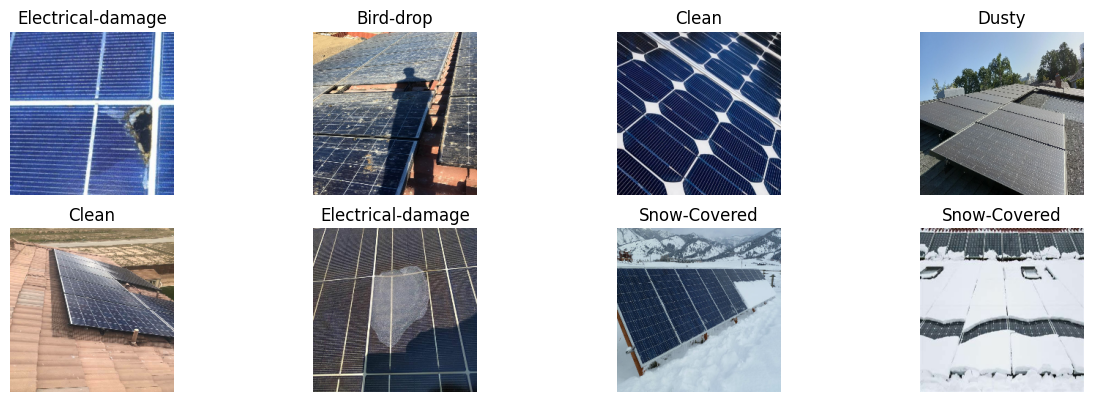

In [ ]:
plt.figure(figsize=(15, 20))
for images, labels in train.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(input_shape=(224,224,3),include_top=False,weights='imagenet')
base_model.trainable = False
keras_model=keras.models.Sequential()
keras_model.add(base_model)
keras_model.add(keras.layers.Flatten())
keras_model.add(keras.layers.Dropout(0.5))
keras_model.add(keras.layers.Dense(6,activation=tf.nn.softmax))
keras_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       169,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,470 (4.23 MB)

 Trainable params: 169,350 (661.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

keras_model = keras.models.Sequential([
    keras.layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation=tf.nn.softmax)
])
keras_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       376,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,310 (10.05 MB)

 Trainable params: 376,326 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
keras_model.build()

In [ ]:
checkpoint =ModelCheckpoint("kkeras_model.keras", save_best_only=True)

In [ ]:
early_stopping =EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
# Start resource tracking for MobileNetV2
mobilenet_ctx = start_training_metrics("MobileNetV2", keras_model)

keras_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
hist = keras_model.fit(train, epochs=25, validation_data=validation,
                       callbacks=[checkpoint, early_stopping, mobilenet_ctx["res_cb"]])


Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 166s 6s/step - accuracy: 0.5311 - loss: 5.2397 - val_accuracy: 0.7966 - val_loss: 1.9348
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8729 - loss: 0.9701 - val_accuracy: 0.8983 - val_loss: 0.9284
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.9364 - loss: 0.4480 - val_accuracy: 0.9322 - val_loss: 0.6085
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9647 - loss: 0.2540 - val_accuracy: 0.9492 - val_loss: 0.5653
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9873 - loss: 0.0451 - val_accuracy: 0.9548 - val_loss: 0.5802
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9760 - loss: 0.1020 - val_accuracy: 0.9435 - val_loss: 0.4789
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9915 - loss: 0.0895 - val_accuracy: 0.9492 - val_loss: 0.4469
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9887 - loss: 0.1319 - val_accuracy: 0.9605 - val_loss

In [ ]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.531073,5.239704,0.796610,1.934788
1,0.872881,0.970144,0.898305,0.928432
2,0.936441,0.448034,0.932203,0.608454
3,0.964689,0.253975,0.949153,0.565278
4,0.987288,0.045121,0.954802,0.580249
5,0.975989,0.101962,0.943503,0.478913
6,0.991525,0.089453,0.949153,0.446922
7,0.988701,0.131936,0.960452,0.453736
8,0.988701,0.072401,0.943503,0.589122
9,0.991525,0.151342,0.949153,0.519218


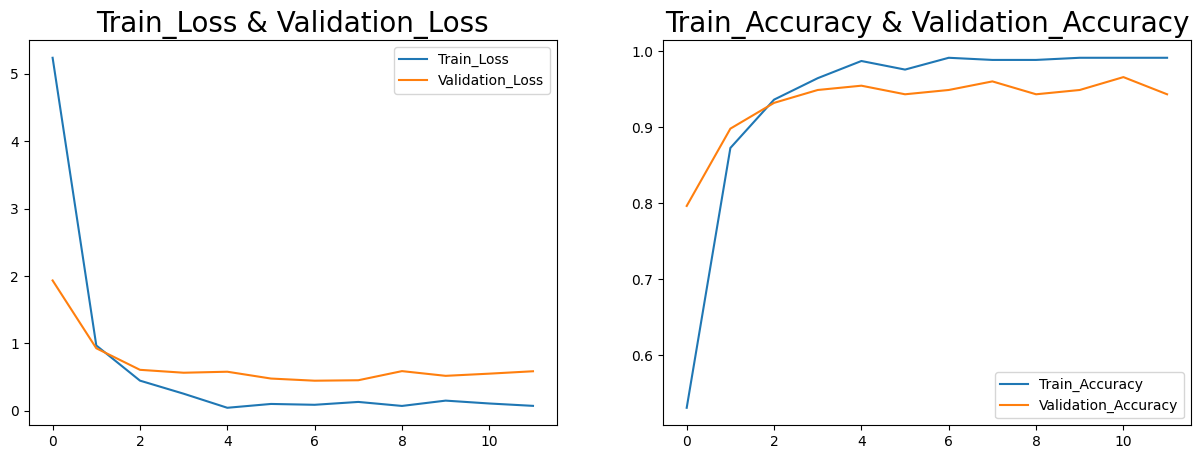

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

In [ ]:
X_val, y_val, y_pred = [], [], []
for images, labels in validation:
    y_val.extend(labels.numpy())
    X_val.extend(images.numpy())
predictions = keras_model.predict(np.array(X_val))
for i in predictions:
    y_pred.append(np.argmax(i))
df = pd.DataFrame()
df['Actual'], df['Prediction'] = y_val, y_pred

mobilenet_entry = stop_training_metrics(mobilenet_ctx, hist, keras_model,
                                         np.array(X_val), np.array(y_val))
df


6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

  MobileNetV2 — resource summary
  Params              : 2,634,310
  Training time       : 2675.9 s
  Epochs run          : 12
  RAM delta           : 1053.8 MB  (before 929.2 → after 1983.0)
  Peak RAM (tracer)   : 335.1 MB
  Peak epoch RAM      : 2073.9 MB
  Infer latency/img   : 67.775 ms
  Val accuracy (best) : 0.9661



,Actual,Prediction
0,1,1
1,3,3
2,3,3
3,5,5
4,3,3
...,...,...
172,1,3
173,0,0
174,1,1
175,1,1


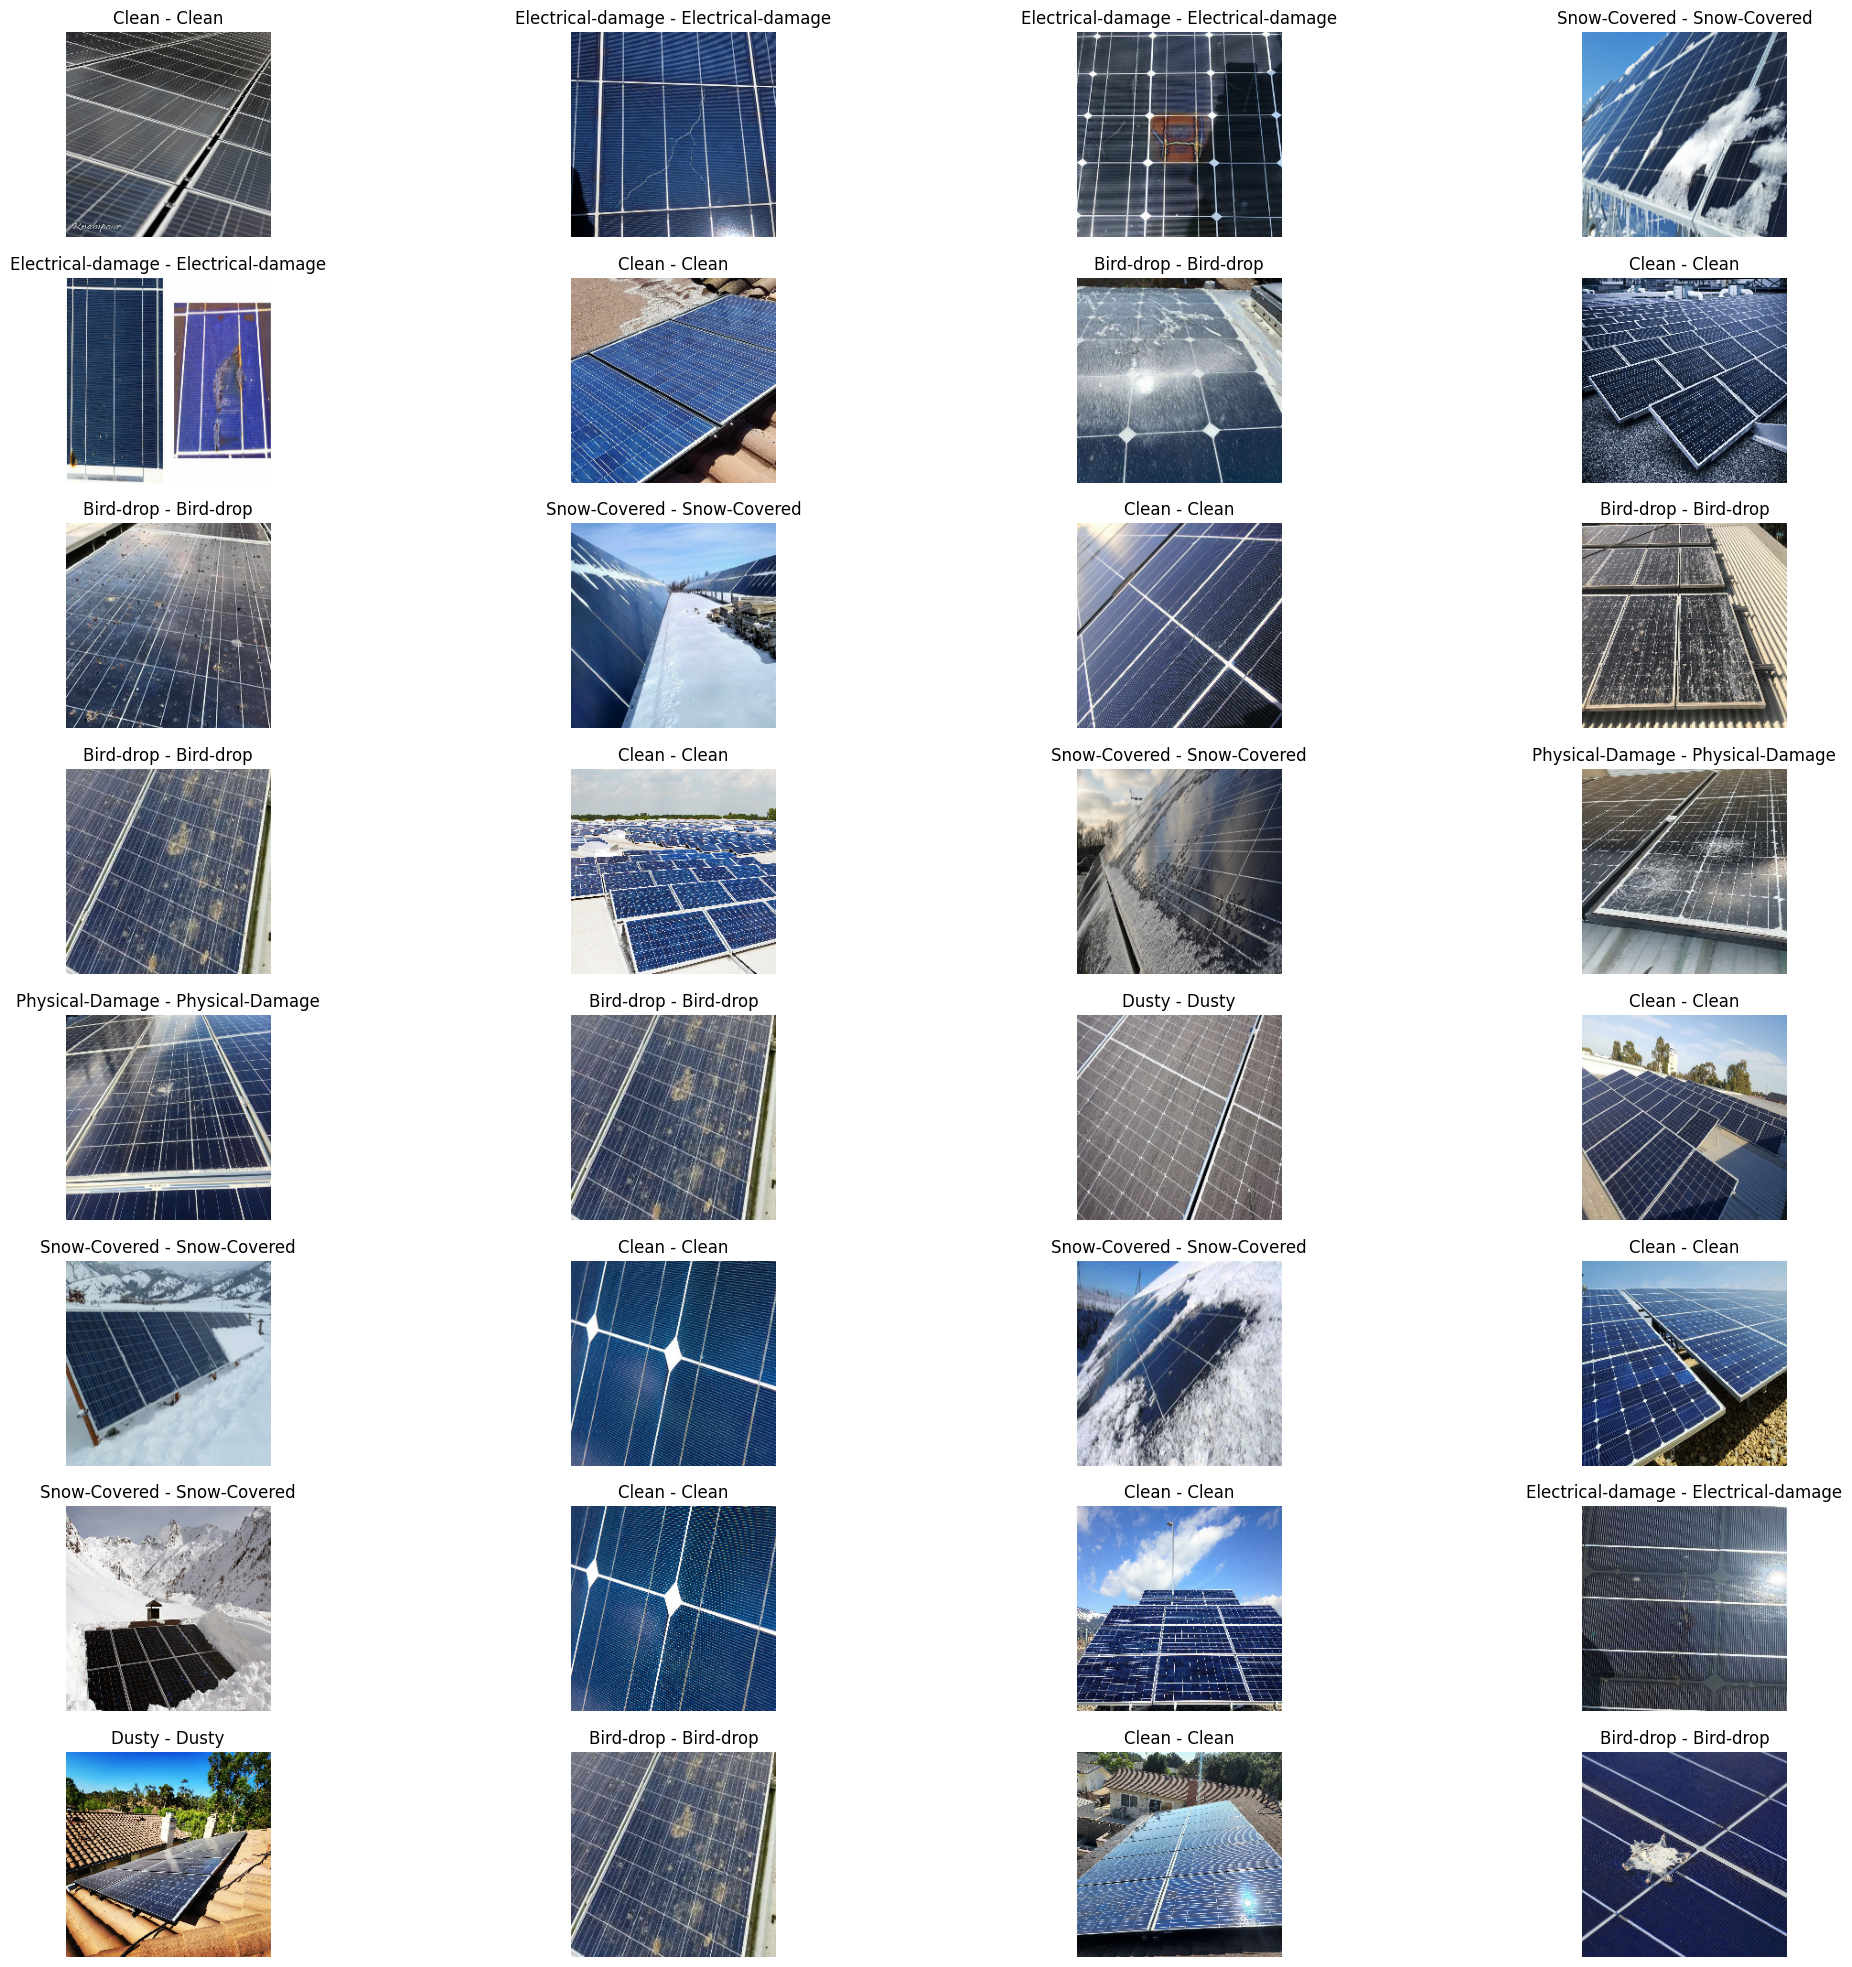

In [ ]:
plt.figure(figsize=(25,25))
for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(X_val[i].astype("uint8"))
    plt.title(f'{class_names[y_val[i]]} - {class_names[y_pred[i]]}')
    plt.axis("off")

In [ ]:
# ── EfficientNetB0 ──────────────────────────────────────────────
eff_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
eff_base.trainable = False

eff_model = keras.models.Sequential([
    eff_base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
eff_checkpoint = ModelCheckpoint("eff_model.keras", save_best_only=True)
eff_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
eff_ctx = start_training_metrics("EfficientNetB0", eff_model)

eff_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
eff_hist = eff_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[eff_checkpoint, eff_early_stopping, eff_ctx["res_cb"]]
)


Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.3178 - loss: 1.6930 - val_accuracy: 0.5141 - val_loss: 1.2414
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.4802 - loss: 1.3076 - val_accuracy: 0.6441 - val_loss: 0.9690
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.6201 - loss: 1.0483 - val_accuracy: 0.7458 - val_loss: 0.8245
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6808 - loss: 0.9275 - val_accuracy: 0.7740 - val_loss: 0.7388
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.7147 - loss: 0.8176 - val_accuracy: 0.7966 - val_loss: 0.6803
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.7458 - loss: 0.7494 - val_accuracy: 0.8079 - val_loss: 0.6304
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.7627 - loss: 0.7071 - val_accuracy: 0.8136 - val_loss: 0.5902
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.7825 - loss: 0.6620 - val_accuracy: 0.8136 - val_

In [ ]:
eff_hist_ = pd.DataFrame(eff_hist.history)
eff_hist_

,accuracy,loss,val_accuracy,val_loss
0,0.317797,1.693028,0.514124,1.241362
1,0.480226,1.307640,0.644068,0.968958
2,0.620057,1.048283,0.745763,0.824467
3,0.680791,0.927495,0.774011,0.738850
4,0.714689,0.817643,0.796610,0.680340
5,0.745763,0.749375,0.807910,0.630447
6,0.762712,0.707140,0.813559,0.590157
7,0.782486,0.662004,0.813559,0.562722
8,0.776836,0.630282,0.819209,0.538287
9,0.795198,0.590140,0.836158,0.511677


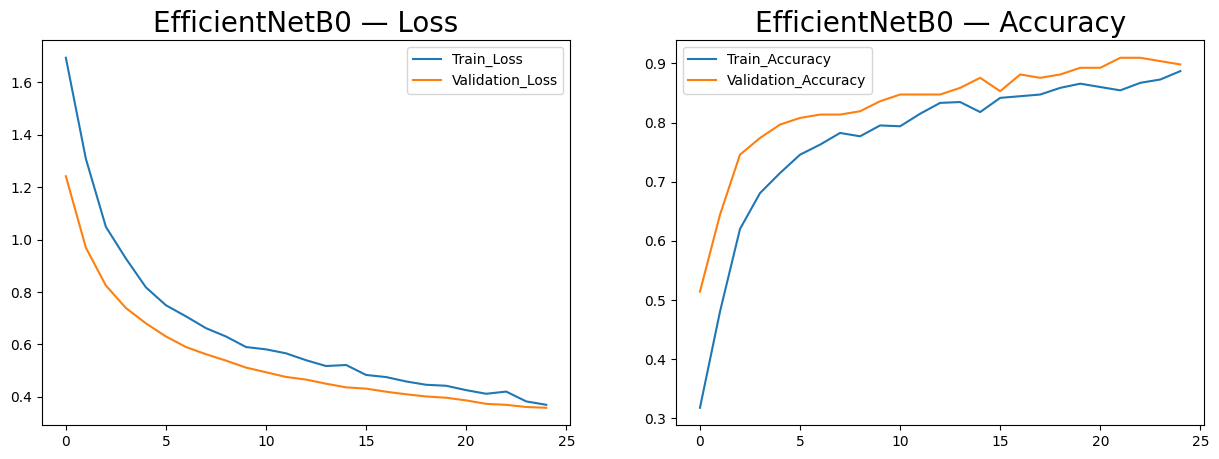

In [ ]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(eff_hist_['loss'], label='Train_Loss')
plt.plot(eff_hist_['val_loss'], label='Validation_Loss')
plt.title('EfficientNetB0 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff_hist_['accuracy'], label='Train_Accuracy')
plt.plot(eff_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('EfficientNetB0 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [ ]:
eff_y_pred = []
predictions_eff = eff_model.predict(np.array(X_val))
for i in predictions_eff:
    eff_y_pred.append(np.argmax(i))

eff_entry = stop_training_metrics(eff_ctx, eff_hist, eff_model,
                                    np.array(X_val), np.array(y_val))

print("EfficientNetB0 Accuracy:", accuracy_score(y_val, eff_y_pred))
print(classification_report(y_val, eff_y_pred, target_names=class_names))


6/6 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step

  EfficientNetB0 — resource summary
  Params              : 4,057,257
  Training time       : 3002.1 s
  Epochs run          : 25
  RAM delta           : 369.7 MB  (before 1834.8 → after 2204.5)
  Peak RAM (tracer)   : 254.3 MB
  Peak epoch RAM      : 2402.3 MB
  Infer latency/img   : 102.85 ms
  Val accuracy (best) : 0.9096

EfficientNetB0 Accuracy: 0.8983050847457628
                   precision    recall  f1-score   support

        Bird-drop       0.90      0.94      0.92        48
            Clean       0.90      0.90      0.90        40
            Dusty       0.84      0.72      0.78        29
Electrical-damage       0.90      0.90      0.90        20
  Physical-Damage       1.00      0.92      0.96        13
     Snow-Covered       0.90      1.00      0.95        27

         accuracy                           0.90       177
        macro avg       0.91      0.90      0.90       177
     weighted avg       0.90      0.90      0.90       17

In [ ]:

def channel_shuffle(x, groups=2):
    return keras.layers.Lambda(
        lambda t: tf.reshape(
            tf.transpose(
                tf.reshape(t, [-1, tf.shape(t)[1], tf.shape(t)[2],
                               groups, tf.shape(t)[3] // groups]),
                perm=[0, 1, 2, 4, 3]
            ),
            [-1, tf.shape(t)[1], tf.shape(t)[2], tf.shape(t)[3]]
        )
    )(x)


def shuffle_unit(x, out_channels, strides, groups=2):
    in_channels = x.shape[-1]
    bottleneck  = out_channels // 4

    if strides == 2:
        shortcut = keras.layers.DepthwiseConv2D(
            kernel_size=3, strides=2, padding='same', use_bias=False)(x)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.Conv2D(
            out_channels // 2, 1, use_bias=False)(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.ReLU()(shortcut)
    else:
        shortcut = x

    residual = keras.layers.Conv2D(bottleneck, 1, use_bias=False)(x)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)
    residual = keras.layers.DepthwiseConv2D(
        kernel_size=3, strides=strides, padding='same', use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.Conv2D(out_channels // 2, 1, use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)

    if strides == 1:
        c  = in_channels // 2
        x1 = keras.layers.Lambda(lambda t: t[:, :, :, :c])(x)
        x2 = keras.layers.Lambda(lambda t: t[:, :, :, c:])(x)
        out = keras.layers.Concatenate()([x2, residual])
    else:
        out = keras.layers.Concatenate()([shortcut, residual])

    out = channel_shuffle(out, groups=2)
    return out


def build_shufflenet(input_shape=(224, 224, 3), num_classes=6):
    """
    ShuffleNetV2 with an improved classification head and augmentation.
    The augmentation layers are training-only (Keras automatically disables
    them during model.predict / model.evaluate).
    """
    inputs = keras.Input(shape=input_shape)

    # ── Built-in augmentation (active only during training) ──────────
    x = keras.layers.RandomFlip("horizontal")(inputs)
    x = keras.layers.RandomRotation(0.1)(x)
    x = keras.layers.RandomZoom(0.1)(x)
    x = keras.layers.RandomBrightness(0.1)(x)          # Keras ≥ 2.13 / TF 2.13+
    # Normalise to [-1, 1]
    x = keras.layers.Rescaling(1.0/127.5, offset=-1.0)(x)

    # ── Backbone ─────────────────────────────────────────────────────
    x = keras.layers.Conv2D(24, 3, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    stages = [(116, 4), (232, 8), (464, 4)]
    for out_ch, repeats in stages:
        x = shuffle_unit(x, out_ch, strides=2)
        for _ in range(repeats - 1):
            x = shuffle_unit(x, out_ch, strides=1)

    x = keras.layers.Conv2D(1024, 1, use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)

    # ── Improved head ─────────────────────────────────────────────────
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(256, activation='swish')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='ShuffleNetV2_Improved')

In [ ]:
shuffle_model = build_shufflenet(input_shape=(224, 224, 3), num_classes=6)
shuffle_model.summary()


Model: "ShuffleNetV2_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness   │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomBrightness)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ random_brightnes… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │        696 │ max_pooling2d[0]… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        116 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 28, 28,    │        216 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 28, 28,    │        261 │ re_lu_2[0][0]     │
│ (DepthwiseConv2D)   │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        116 │ depthwise_conv2d

 Total params: 1,317,538 (5.03 MB)

 Trainable params: 1,303,486 (4.97 MB)

 Non-trainable params: 14,052 (54.89 KB)

In [ ]:
shuffle_checkpoint     = ModelCheckpoint("shuffle_model.keras", save_best_only=True)
shuffle_early_stopping = EarlyStopping(patience=7, restore_best_weights=True)

# Cosine-decay LR schedule for Phase-2
def cosine_lr_schedule(epoch, lr):
    import math
    min_lr, max_lr = 1e-6, 1e-4
    T = 30   # half-cycle length
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / T))

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(cosine_lr_schedule, verbose=0)

In [ ]:
def sparse_smooth_loss(num_classes=6, smoothing=0.1):
    cce = keras.losses.CategoricalCrossentropy(label_smoothing=smoothing)
    def _loss(y_true, y_pred):
        y_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
        return cce(y_one_hot, y_pred)
    return _loss

smooth_loss = sparse_smooth_loss(num_classes=6, smoothing=0.1)

# ── Phase-1: fast head convergence (LR = 1e-3) ───────────────────────
shuffle_ctx = start_training_metrics("ShuffleNetV2", shuffle_model)
shuffle_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=smooth_loss,
    metrics=['accuracy']
)
shuffle_hist_p1 = shuffle_model.fit(
    train, epochs=20,
    validation_data=validation,
    callbacks=[shuffle_checkpoint, shuffle_early_stopping, shuffle_ctx["res_cb"]]
)

# ── Phase-2: fine-tune all layers with cosine LR (LR = 1e-4) ─────────
shuffle_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=smooth_loss,
    metrics=['accuracy']
)
shuffle_hist = shuffle_model.fit(
    train, epochs=30,
    validation_data=validation,
    callbacks=[shuffle_checkpoint,
               EarlyStopping(patience=7, restore_best_weights=True),
               lr_scheduler,
               shuffle_ctx["res_cb"]]
)

# ── Merge Phase-1 + Phase-2 histories safely ─────────────────────────
# Early stopping can cause Phase-1 and Phase-2 to run different numbers
# of epochs. Some keys (e.g. 'lr') only appear in one phase. We only
# keep keys that exist in BOTH phases so all arrays are the same length.
import collections

p1_keys = set(shuffle_hist_p1.history.keys())
p2_keys = set(shuffle_hist.history.keys())
shared_keys = p1_keys & p2_keys          # intersection — always same length

shuffle_hist_merged = {}
for k in shared_keys:
    shuffle_hist_merged[k] = (shuffle_hist_p1.history[k] +
                               shuffle_hist.history[k])

shuffle_hist_ = pd.DataFrame(shuffle_hist_merged)
print(f"Phase-1 epochs: {len(shuffle_hist_p1.history['loss'])}  |  "
      f"Phase-2 epochs: {len(shuffle_hist.history['loss'])}  |  "
      f"Total: {len(shuffle_hist_merged['loss'])}")

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 234s 5s/step - accuracy: 0.2585 - loss: 2.5091 - val_accuracy: 0.2712 - val_loss: 1.7711
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.3107 - loss: 2.3330 - val_accuracy: 0.2712 - val_loss: 1.7517
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.3037 - loss: 2.3527 - val_accuracy: 0.1525 - val_loss: 1.7893
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.3107 - loss: 2.2301 - val_accuracy: 0.2712 - val_loss: 1.7399
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.3460 - loss: 2.3346 - val_accuracy: 0.2712 - val_loss: 1.7681
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.3559 - loss: 2.0687 - val_accuracy: 0.2260 - val_loss: 1.8237
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.3263 - loss: 2.0462 - val_accuracy: 0.2260 - val_loss: 2.0424
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.3446 - loss: 1.8898 - val_accuracy: 0.2712 - val

In [38]:
class _MergedHist:
    def __init__(self, d): self.history = d

shuffle_entry = stop_training_metrics(shuffle_ctx, _MergedHist(shuffle_hist_merged),
                                       shuffle_model, np.array(X_val), np.array(y_val))


  ShuffleNetV2 — resource summary
  Params              : 1,317,538
  Training time       : 5226.0 s
  Epochs run          : 19
  RAM delta           : 1427.4 MB  (before 2768.5 → after 4195.9)
  Peak RAM (tracer)   : 336.2 MB
  Peak epoch RAM      : 4217.8 MB
  Infer latency/img   : 39.63 ms
  Val accuracy (best) : 0.2712



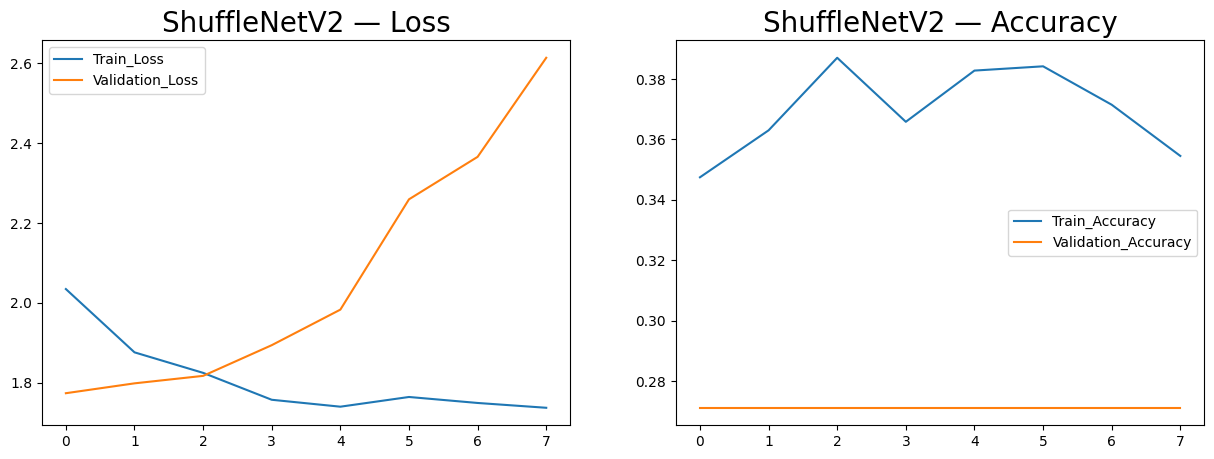

In [37]:
shuffle_hist_ = pd.DataFrame(shuffle_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(shuffle_hist_['loss'], label='Train_Loss')
plt.plot(shuffle_hist_['val_loss'], label='Validation_Loss')
plt.title('ShuffleNetV2 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(shuffle_hist_['accuracy'], label='Train_Accuracy')
plt.plot(shuffle_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('ShuffleNetV2 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [39]:
shuffle_y_pred = []
predictions_shuffle = shuffle_model.predict(np.array(X_val))
for i in predictions_shuffle:
    shuffle_y_pred.append(np.argmax(i))

print("ShuffleNetV2 Accuracy:", accuracy_score(y_val, shuffle_y_pred))
print(classification_report(y_val, shuffle_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
ShuffleNetV2 Accuracy: 0.2711864406779661
                   precision    recall  f1-score   support

        Bird-drop       0.27      1.00      0.43        48
            Clean       0.00      0.00      0.00        40
            Dusty       0.00      0.00      0.00        29
Electrical-damage       0.00      0.00      0.00        20
  Physical-Damage       0.00      0.00      0.00        13
     Snow-Covered       0.00      0.00      0.00        27

         accuracy                           0.27       177
        macro avg       0.05      0.17      0.07       177
     weighted avg       0.07      0.27      0.12       177



In [40]:
# ── VGG16 ────────────────────────────────────────────────────────
vgg_base = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
vgg_base.trainable = False

vgg_model = keras.models.Sequential([
    vgg_base,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [41]:
vgg_checkpoint = ModelCheckpoint("vgg_model.keras", save_best_only=True)
vgg_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [42]:
vgg_ctx = start_training_metrics("VGG16", vgg_model)

vgg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
vgg_hist = vgg_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[vgg_checkpoint, vgg_early_stopping, vgg_ctx["res_cb"]]
)


Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 608s 26s/step - accuracy: 0.4534 - loss: 21.7868 - val_accuracy: 0.8136 - val_loss: 3.4602
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 639s 27s/step - accuracy: 0.7472 - loss: 3.0685 - val_accuracy: 0.8927 - val_loss: 0.7905
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 608s 27s/step - accuracy: 0.8319 - loss: 1.3518 - val_accuracy: 0.8588 - val_loss: 1.0252
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 599s 26s/step - accuracy: 0.8404 - loss: 1.0905 - val_accuracy: 0.8870 - val_loss: 0.4855
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 600s 26s/step - accuracy: 0.8319 - loss: 0.9098 - val_accuracy: 0.9096 - val_loss: 0.4929
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 644s 27s/step - accuracy: 0.8912 - loss: 0.5742 - val_accuracy: 0.8927 - val_loss: 0.5332
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 626s 27s/step - accuracy: 0.8771 - loss: 0.6238 - val_accuracy: 0.9153 - val_loss: 0.4689
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 601s 26s/step - accuracy: 0.9011 - loss: 0.4266 - val_accuracy: 0

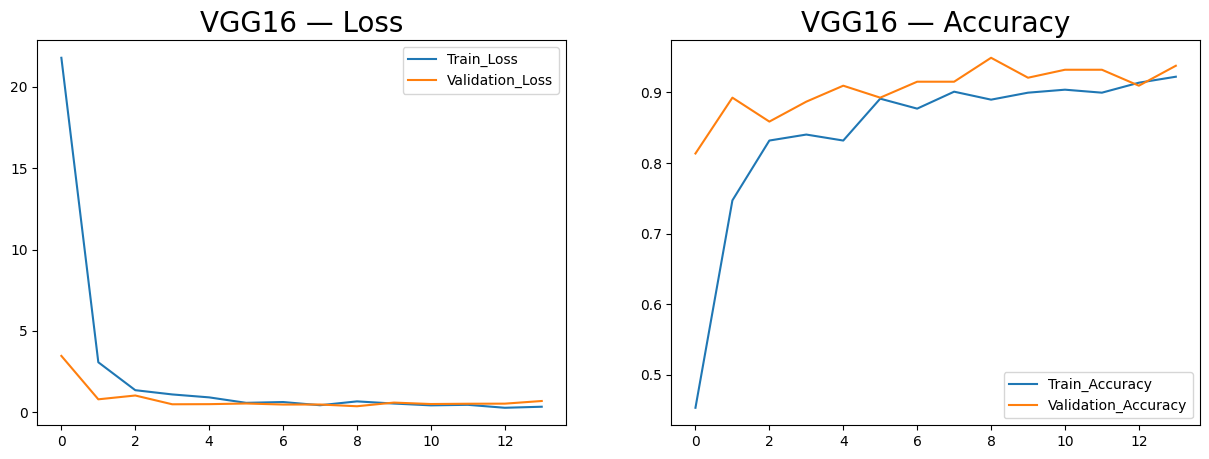

In [43]:
vgg_hist_ = pd.DataFrame(vgg_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_hist_['loss'], label='Train_Loss')
plt.plot(vgg_hist_['val_loss'], label='Validation_Loss')
plt.title('VGG16 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_hist_['accuracy'], label='Train_Accuracy')
plt.plot(vgg_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('VGG16 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [45]:
vgg_y_pred = []
predictions_vgg = vgg_model.predict(np.array(X_val))
for i in predictions_vgg:
    vgg_y_pred.append(np.argmax(i))

vgg_entry = stop_training_metrics(vgg_ctx, vgg_hist, vgg_model,
                                    np.array(X_val), np.array(y_val))

print("VGG16 Accuracy:", accuracy_score(y_val, vgg_y_pred))
print(classification_report(y_val, vgg_y_pred, target_names=class_names))


6/6 ━━━━━━━━━━━━━━━━━━━━ 142s 20s/step

  VGG16 — resource summary
  Params              : 21,139,014
  Training time       : 8924.2 s
  Epochs run          : 14
  RAM delta           : 705.0 MB  (before 3521.1 → after 4226.1)
  Peak RAM (tracer)   : 332.3 MB
  Peak epoch RAM      : 4244.9 MB
  Infer latency/img   : 842.123 ms
  Val accuracy (best) : 0.9492

VGG16 Accuracy: 0.9491525423728814
                   precision    recall  f1-score   support

        Bird-drop       0.94      0.96      0.95        48
            Clean       0.97      0.95      0.96        40
            Dusty       0.86      0.86      0.86        29
Electrical-damage       1.00      1.00      1.00        20
  Physical-Damage       1.00      0.92      0.96        13
     Snow-Covered       0.96      1.00      0.98        27

         accuracy                           0.95       177
        macro avg       0.96      0.95      0.95       177
     weighted avg       0.95      0.95      0.95       177



Model                Val Accuracy
MobileNetV2                0.9492
EfficientNetB0             0.8983
ShuffleNetV2               0.2712
VGG16                      0.9492


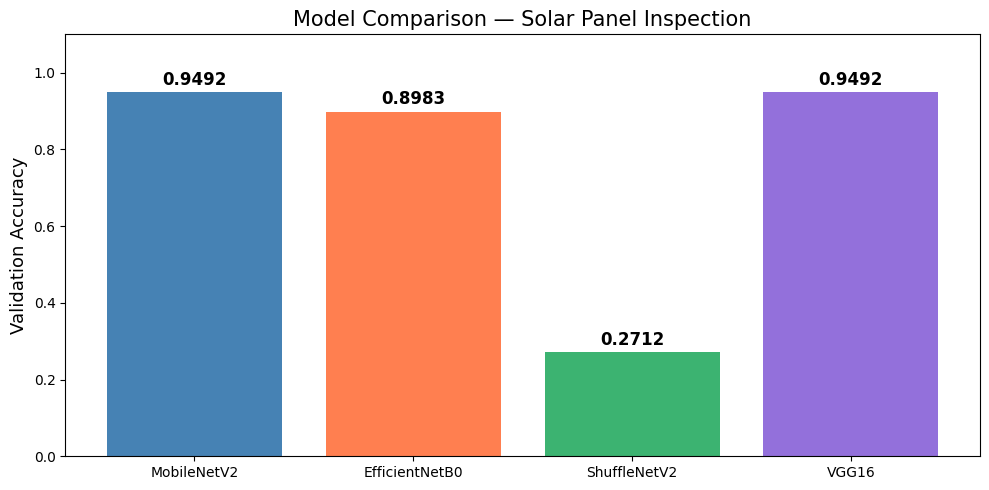

In [46]:
results = {
    'MobileNetV2':    accuracy_score(y_val, y_pred),
    'EfficientNetB0': accuracy_score(y_val, eff_y_pred),
    'ShuffleNetV2':   accuracy_score(y_val, shuffle_y_pred),
    'VGG16':          accuracy_score(y_val, vgg_y_pred),
}

print("=" * 42)
print(f"{'Model':<20} {'Val Accuracy':>12}")
print("=" * 42)
for model_name, acc in results.items():
    print(f"{model_name:<20} {acc:>12.4f}")
print("=" * 42)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('Model Comparison — Solar Panel Inspection', fontsize=15)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f"{acc:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

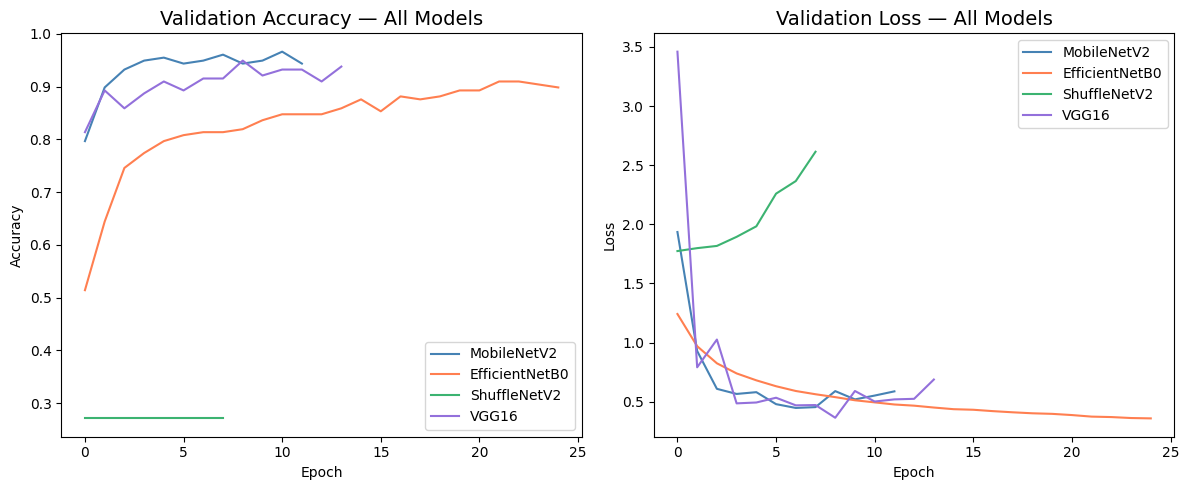

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_['val_accuracy'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_accuracy'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_accuracy'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_accuracy'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Accuracy — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_['val_loss'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_loss'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_loss'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_loss'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Loss — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
# ════════════════════════════════════════════════════════════════════
#  COMPREHENSIVE RESOURCE + ACCURACY COMPARISON
# ════════════════════════════════════════════════════════════════════

summary_data = {
    'Model':                ['MobileNetV2', 'EfficientNetB0', 'ShuffleNetV2', 'VGG16'],
    'Type':                 ['Lightweight', 'Lightweight', 'Lightweight', 'Heavyweight'],
    'Val Accuracy':         [
        round(accuracy_score(y_val, y_pred), 4),
        round(accuracy_score(y_val, eff_y_pred), 4),
        round(accuracy_score(y_val, shuffle_y_pred), 4),
        round(accuracy_score(y_val, vgg_y_pred), 4),
    ],
}

# Pull resource metrics from the global log
for key in ['total_params', 'train_time_s', 'ram_delta_mb',
            'peak_epoch_ram_mb', 'vram_delta_mb', 'peak_epoch_vram_mb',
            'infer_ms_per_image', 'epochs_run']:
    summary_data[key] = [
        _metrics_log.get(m, {}).get(key, 'N/A')
        for m in summary_data['Model']
    ]

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("FULL RESOURCE & ACCURACY SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)
summary_df



FULL RESOURCE & ACCURACY SUMMARY
         Model        Type  Val Accuracy  total_params  train_time_s  ram_delta_mb  peak_epoch_ram_mb  vram_delta_mb  peak_epoch_vram_mb  infer_ms_per_image  epochs_run
   MobileNetV2 Lightweight        0.9492       2634310        2675.9        1053.8             2073.9            0.0                 0.0              67.775          12
         VGG16 Heavyweight        0.9492      21139014        8924.2         705.0             4244.9            0.0                 0.0             842.123          14
EfficientNetB0 Lightweight        0.8983       4057257        3002.1         369.7             2402.3            0.0                 0.0             102.850          25
  ShuffleNetV2 Lightweight        0.2712       1317538        5226.0        1427.4             4217.8            0.0                 0.0              39.630          19


,Model,Type,Val Accuracy,total_params,train_time_s,ram_delta_mb,peak_epoch_ram_mb,vram_delta_mb,peak_epoch_vram_mb,infer_ms_per_image,epochs_run
0,MobileNetV2,Lightweight,0.9492,2634310,2675.9,1053.8,2073.9,0.0,0.0,67.775,12
1,VGG16,Heavyweight,0.9492,21139014,8924.2,705.0,4244.9,0.0,0.0,842.123,14
2,EfficientNetB0,Lightweight,0.8983,4057257,3002.1,369.7,2402.3,0.0,0.0,102.850,25
3,ShuffleNetV2,Lightweight,0.2712,1317538,5226.0,1427.4,4217.8,0.0,0.0,39.630,19


## Resource Usage Visualisations

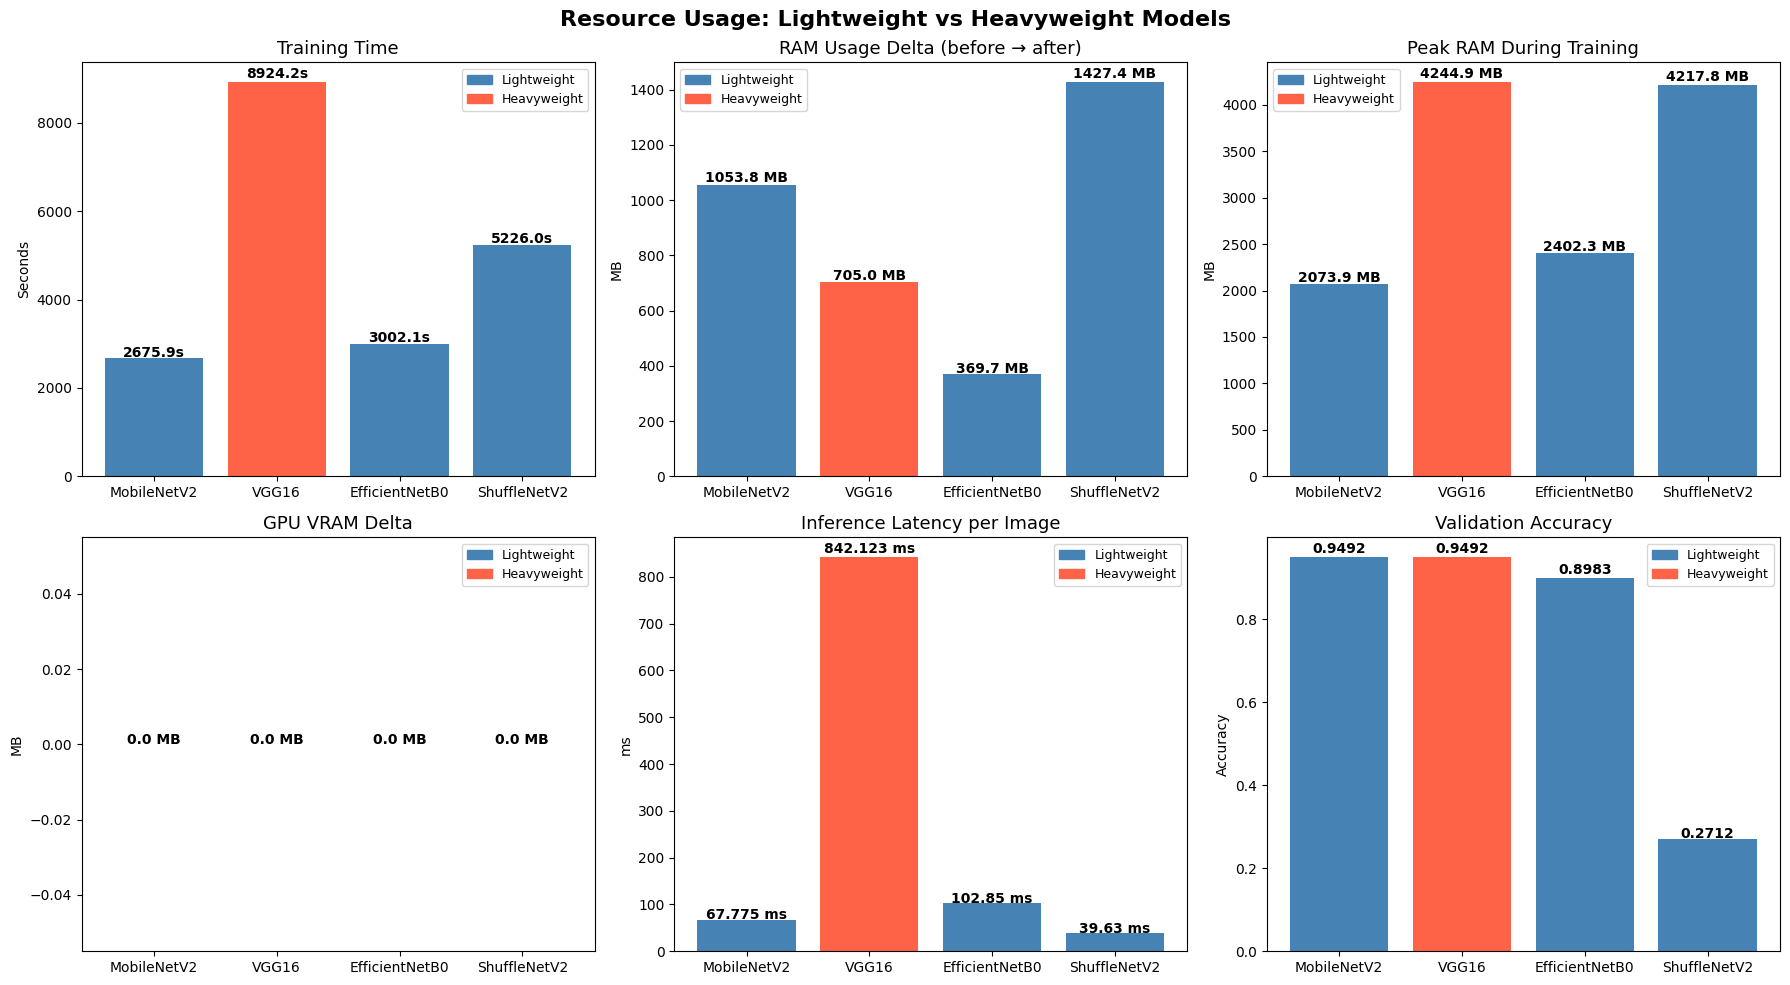

In [49]:
# ── Plot 1: Training time comparison ─────────────────────────────────
models      = summary_df['Model'].tolist()
colors_map  = {'Lightweight': 'steelblue', 'Heavyweight': 'tomato'}
bar_colors  = [colors_map[t] for t in summary_df['Type']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Resource Usage: Lightweight vs Heavyweight Models', fontsize=16, fontweight='bold')

def _bar(ax, values, title, ylabel, unit=""):
    bars = ax.bar(models, values, color=bar_colors)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, values):
        if v != 'N/A':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f"{v}{unit}", ha='center', fontsize=10, fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Lightweight'),
                        Patch(color='tomato',    label='Heavyweight')],
              fontsize=9)

_bar(axes[0,0], summary_df['train_time_s'].tolist(),
     'Training Time', 'Seconds', 's')
_bar(axes[0,1], summary_df['ram_delta_mb'].tolist(),
     'RAM Usage Delta (before → after)', 'MB', ' MB')
_bar(axes[0,2], summary_df['peak_epoch_ram_mb'].tolist(),
     'Peak RAM During Training', 'MB', ' MB')
_bar(axes[1,0], summary_df['vram_delta_mb'].tolist(),
     'GPU VRAM Delta', 'MB', ' MB')
_bar(axes[1,1], summary_df['infer_ms_per_image'].tolist(),
     'Inference Latency per Image', 'ms', ' ms')
_bar(axes[1,2], summary_df['Val Accuracy'].tolist(),
     'Validation Accuracy', 'Accuracy', '')

plt.tight_layout()
plt.show()


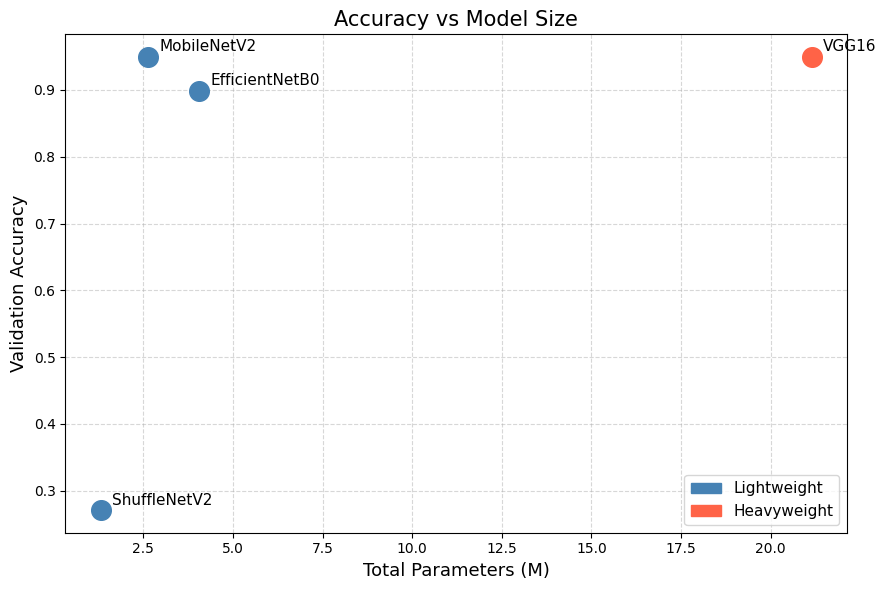

In [50]:
# ── Plot 2: Params vs Accuracy scatter ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in summary_df.iterrows():
    color = colors_map[row['Type']]
    ax.scatter(row['total_params'] / 1e6, row['Val Accuracy'],
               s=200, color=color, zorder=3)
    ax.annotate(row['Model'],
                (row['total_params'] / 1e6, row['Val Accuracy']),
                textcoords="offset points", xytext=(8, 4), fontsize=11)
ax.set_xlabel('Total Parameters (M)', fontsize=13)
ax.set_ylabel('Validation Accuracy', fontsize=13)
ax.set_title('Accuracy vs Model Size', fontsize=15)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Lightweight'),
                    Patch(color='tomato',    label='Heavyweight')], fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


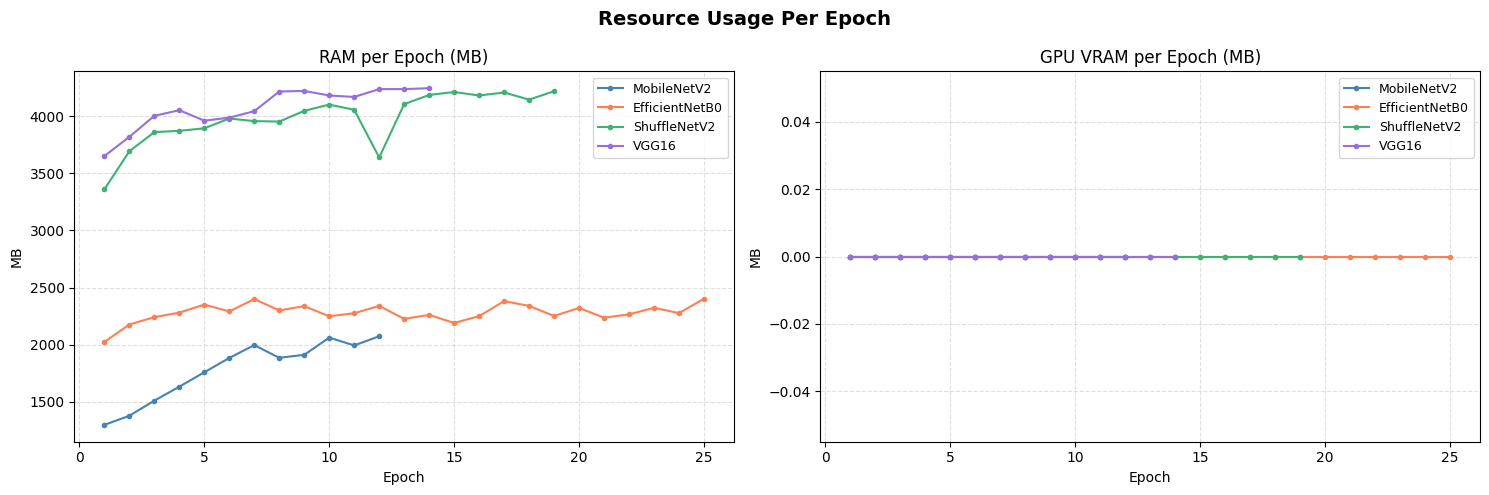

In [51]:
# ── Plot 3: RAM usage per epoch for all models ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Resource Usage Per Epoch', fontsize=14, fontweight='bold')

color_cycle = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for ax_idx, metric_key, title in [
    (0, 'epoch_ram_samples',  'RAM per Epoch (MB)'),
    (1, 'epoch_vram_samples', 'GPU VRAM per Epoch (MB)'),
]:
    for (mname, color) in zip(['MobileNetV2','EfficientNetB0','ShuffleNetV2','VGG16'], color_cycle):
        samples = _metrics_log.get(mname, {}).get(metric_key, [])
        if samples:
            axes[ax_idx].plot(range(1, len(samples)+1), samples,
                               label=mname, color=color, marker='o', markersize=3)
    axes[ax_idx].set_xlabel('Epoch')
    axes[ax_idx].set_ylabel('MB')
    axes[ax_idx].set_title(title, fontsize=12)
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [52]:
# ── Final resource summary table (styled) ────────────────────────────
display_cols = ['Model', 'Type', 'total_params', 'train_time_s',
                'ram_delta_mb', 'peak_epoch_ram_mb',
                'vram_delta_mb', 'infer_ms_per_image', 'Val Accuracy']
rename_map = {
    'total_params'       : 'Params',
    'train_time_s'       : 'Train Time (s)',
    'ram_delta_mb'       : 'RAM Δ (MB)',
    'peak_epoch_ram_mb'  : 'Peak RAM (MB)',
    'vram_delta_mb'      : 'VRAM Δ (MB)',
    'infer_ms_per_image' : 'Infer (ms/img)',
    'Val Accuracy'       : 'Val Accuracy',
}
final_table = summary_df[display_cols].rename(columns=rename_map)
print(final_table.to_string(index=False))


         Model        Type   Params  Train Time (s)  RAM Δ (MB)  Peak RAM (MB)  VRAM Δ (MB)  Infer (ms/img)  Val Accuracy
   MobileNetV2 Lightweight  2634310          2675.9      1053.8         2073.9          0.0          67.775        0.9492
         VGG16 Heavyweight 21139014          8924.2       705.0         4244.9          0.0         842.123        0.9492
EfficientNetB0 Lightweight  4057257          3002.1       369.7         2402.3          0.0         102.850        0.8983
  ShuffleNetV2 Lightweight  1317538          5226.0      1427.4         4217.8          0.0          39.630        0.2712
